# Multi-Linear Regression

the objective: this notebook aims to use regression to predict the wave hights, and uses metrics to check the prediction accuracy.

# Import the Data

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

In [45]:
data=pd.read_csv("../data/clean/cleandata.csv",index_col="time", parse_dates=True)

In [46]:
data.columns

Index(['Y', 'M', 'D', 'h', 'm', 'wind direction', 'Wind speed', 'Wind gust',
       'Significant wave height', 'Atmospheric pressure', 'wind_dir_x',
       'wind_dir_y'],
      dtype='object')

In [47]:
data.head()

,Y,M,D,h,m,wind direction,Wind speed,Wind gust,Significant wave height,Atmospheric pressure,wind_dir_x,wind_dir_y
time,,,,,,,,,,,,
2022-03-02 20:40:00,2022,3,2,20,40,234,8.3,10.8,1.31,1017.5,-0.587785,-0.809017
2022-03-02 21:40:00,2022,3,2,21,40,236,9.3,11.5,1.46,1017.7,-0.559193,-0.829038
2022-03-02 22:40:00,2022,3,2,22,40,235,7.7,9.6,1.63,1018.0,-0.573576,-0.819152
2022-03-02 23:40:00,2022,3,2,23,40,230,7.3,10.7,1.40,1018.3,-0.642788,-0.766044
2022-03-03 00:40:00,2022,3,3,0,40,209,4.9,6.5,1.32,1018.7,-0.874620,-0.484810


# Train & Test Split

In [48]:
from sklearn.model_selection import train_test_split

In [49]:
X= data[['Wind speed', 'Wind gust', 'Atmospheric pressure', 'wind_dir_x',
       'wind_dir_y']]
Y= data['Significant wave height']

In [50]:
X_train, X_test ,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,shuffle=False)

# Multi-Linear Regression

In [51]:
from sklearn.linear_model import LinearRegression

In [52]:
lr=LinearRegression()

In [53]:
lr.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[-0.43, 0.5 ,-0.03, 0.22, 0.03]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Wind speed','Wind gust','Atmospheric pressure','wind_dir_x','wind_dir_y']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,32.03
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5


In [54]:
Y_pred=lr.predict(X_test)

# Checking the Metrics

In [55]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

In [56]:
mae = mean_absolute_error(Y_test, Y_pred)

In [57]:
rmse = root_mean_squared_error(Y_test, Y_pred)

In [58]:
r2s= r2_score(Y_test, Y_pred)

In [59]:
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2s)

MAE: 0.45853244892063505
RMSE: 0.713713651729183
R²: 0.5495571973778898


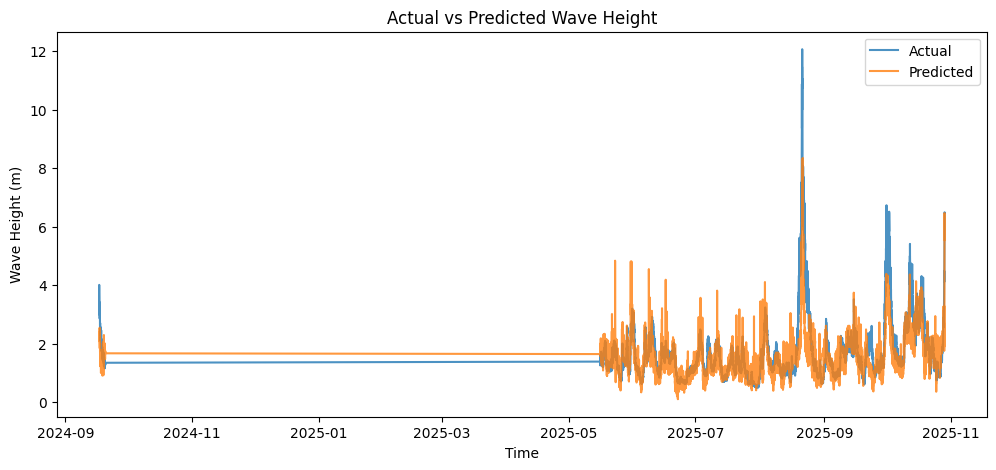

In [60]:
plt.figure(figsize=(12,5))
plt.plot(Y_test.index, Y_test.values, label='Actual', alpha=0.8)
plt.plot(Y_test.index, Y_pred, label='Predicted', alpha=0.8)
plt.xlabel('Time')
plt.ylabel('Wave Height (m)')
plt.title('Actual vs Predicted Wave Height')
plt.legend()
plt.show()

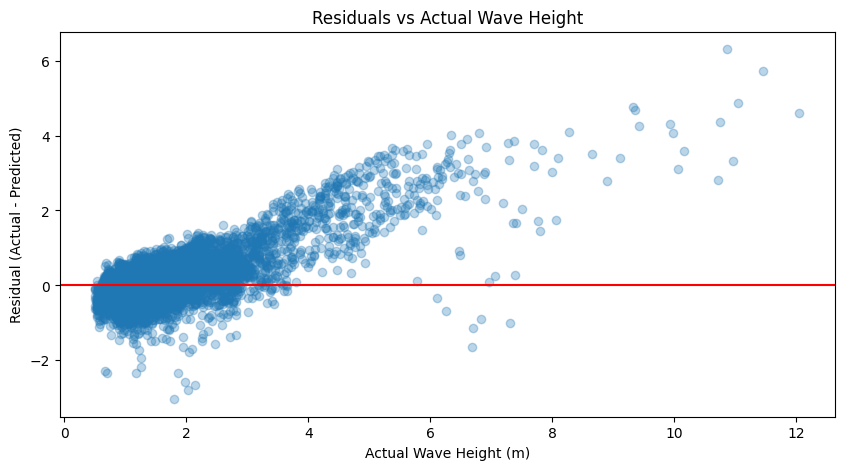

In [61]:
residuals = Y_test - Y_pred
plt.figure(figsize=(10,5))
plt.scatter(Y_test, residuals, alpha=0.3)
plt.axhline(0, color='red')
plt.xlabel('Actual Wave Height (m)')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residuals vs Actual Wave Height')
plt.show()

In [62]:
low_mask = Y_test < 3
high_mask = Y_test >= 5

print("MAE, low waves (<3m):", mean_absolute_error(Y_test[low_mask], Y_pred[low_mask]))
print("MAE, high waves (>=5m):", mean_absolute_error(Y_test[high_mask], Y_pred[high_mask]))

MAE, low waves (<3m): 0.3450978734484881
MAE, high waves (>=5m): 2.6928976143815873


# Gradiant decent & the coeff

In [ ]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

In [71]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [73]:
GD = SGDRegressor(
    learning_rate="constant",
    eta0=0.001,
    max_iter=1000,
    random_state=42
)
GD.fit(X_train_scaled, Y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"learning_rate learning_rate: str, default='invscaling'The learning rate schedule:- 'constant': `eta = eta0`- 'optimal': `eta = 1.0 / (alpha * (t + t0))` where t0 is chosen by a heuristic proposed by Leon Bottou.- 'invscaling': `eta = eta0 / pow(t, power_t)`- 'adaptive': eta = eta0, as long as the training keeps decreasing. Each time n_iter_no_change consecutive epochs fail to decrease the training loss by tol or fail to increase validation score by tol if early_stopping is True, the current learning rate is divided by 5.- 'pa1': passive-aggressive algorithm 1, see [1]_. Only with `loss='epsilon_insensitive'`. Update is `w += eta y x` with `eta = min(eta0, loss/||x||**2)`.- 'pa2': passive-aggressive algorithm 2, see [1]_. Only with `loss='epsilon_insensitive'`. Update is `w += eta y x` with `eta = hinge_loss / (||x||**2 + 1/(2 eta0))`... versionadded:: 0.20 Added 'adaptive' option... versionadded:: 1.8 Added options 'pa1' and 'pa2'",'constant'
,"eta0 eta0: float, default=0.01The initial learning rate for the 'constant', 'invscaling' or'adaptive' schedules. The default value is 0.01.Values must be in the range `(0.0, inf)`.For PA-1 (`learning_rate=pa1`) and PA-II (`pa2`), it specifies theaggressiveness parameter for the passive-aggressive algorithm, see [1] where itis called C:- For PA-I it is the maximum step size.- For PA-II it regularizes the step size (the smaller `eta0` the more it regularizes).As a general rule-of-thumb for PA, `eta0` should be small when the data isnoisy.",0.001
,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide <sgd_mathematical_formulation>`.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None,

In [74]:
print(GD)

SGDRegressor(eta0=0.001, learning_rate='constant', random_state=42)


In [75]:
GD.intercept_
GD.coef_

array([-1.29291465e+00,  1.89259154e+00, -1.95458835e-01,  1.77521106e-01,
       -1.15582046e-03])

# Linear Regression Vs Gradiant dcent coeff

In [76]:
from sklearn.linear_model import LinearRegression

LR = LinearRegression()
LR.fit(X_train_scaled, Y_train)

print("Linear Regression coefficients:")
print(LR.coef_)
print("Intercept:", LR.intercept_)

print("\nSGD coefficients:")
print(GD.coef_)
print("Intercept:", GD.intercept_)

Linear Regression coefficients:
[-1.35378996  1.95101776 -0.18334234  0.15969852  0.01709266]
Intercept: 1.8648727114482009

SGD coefficients:
[-1.29291465e+00  1.89259154e+00 -1.95458835e-01  1.77521106e-01
 -1.15582046e-03]
Intercept: [1.85219292]
